#### Import Libraries

In [24]:
import numpy as np

import torch
import torch.nn as nn

import librosa
import librosa.display

import seaborn as sns
import matplotlib.pyplot as plt

As we have noticed the class imbalance of our data in [EDA module](https://github.com/Ankit6174/Acoustic-Modeling-for-Pulmonary-Disease-Classification/blob/main/EDA.ipynb). We have to augment data in order to acheive more impactful results. Some class for example, Asthma and LRTI must drop because of too less class counts.

And other classes like Healthy and Pneumonia has enough number of samples to augment data.

There are some techniques we can use to augment data for audio. Just like image augmentation (rotate, brightness, shifting, and etc) we have some audio domain augmentation techniques.

In [25]:
# Load waveform
waveform, sr = librosa.load(r"ICBHI_final_database\101_1b1_Al_sc_Meditron.wav", sr=16000)
waveform = waveform[:16000] # We are only using 1 second waveform to visually it clearly.

#### Noise injection

We can simply introduce noise or more specifically gaussian noise to our waveform, which will create another but similary waveform.

We are using gaussian noise because normal or gaussian curve is more predictable.

Text(0.5, 36.72222222222221, 'After White Noise Injection')

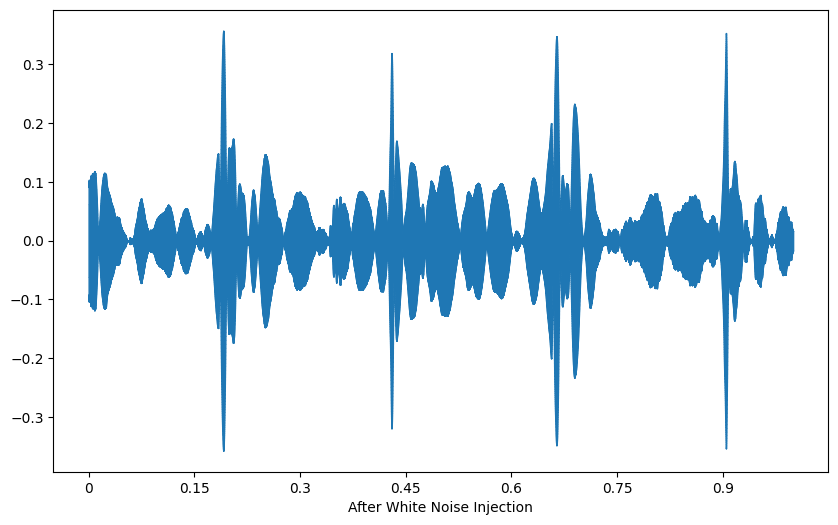

In [26]:
noise_factor = 0.0005  
white_noise = np.random.randn(len(waveform)) * noise_factor
waveform_white_noise = waveform + white_noise

plt.figure(figsize=(10, 6))
librosa.display.waveshow(waveform, sr=sr)
plt.xlabel("After White Noise Injection")

#### Shifting

We can also shift our audio file, all we need to do is to add the (lenght of waveform - shift size) in the front of the waveform. Don't worry, thank to numpy it is easy!

Text(0.5, 36.72222222222221, 'After Shifting')

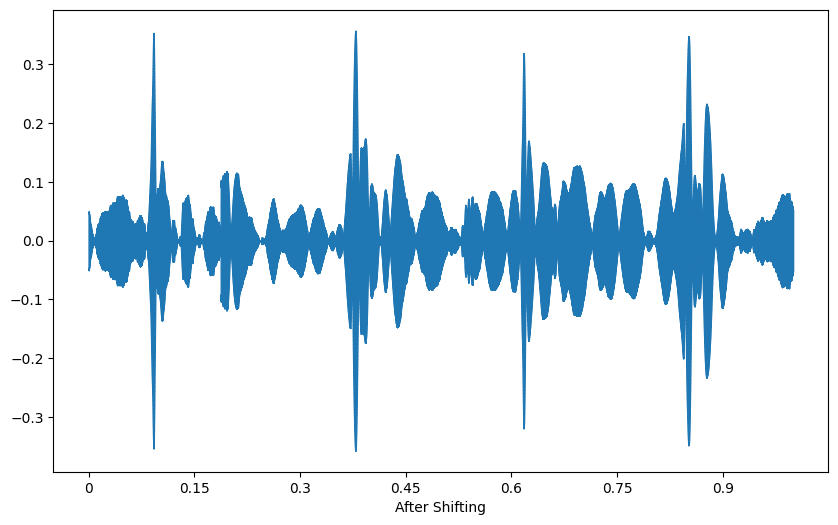

In [27]:
shifted_waveform = np.roll(waveform, 3000) # You can sift if seconds with simple (seconds * sampling rate)

plt.figure(figsize=(10, 6))
librosa.display.waveshow(shifted_waveform, sr=sr)
plt.xlabel("After Shifting")

#### Stretch Audio

Text(0.5, 36.72222222222221, 'After Stretching')

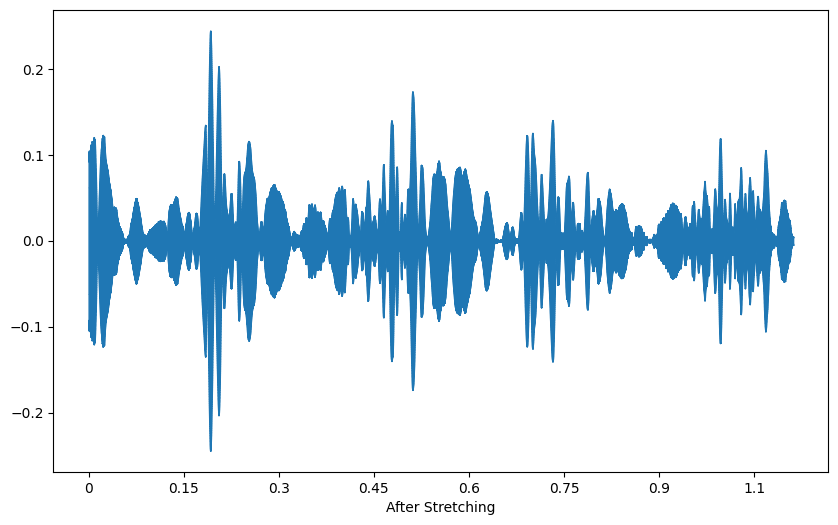

In [28]:
rate = 0.9  
stretched_waveform = librosa.effects.time_stretch(waveform, rate=rate)

plt.figure(figsize=(10, 6))
librosa.display.waveshow(stretched_waveform, sr=sr)
plt.xlabel("After Stretching")

#### Alter frequency or Pitch

Text(0.5, 36.72222222222221, 'Altered Pitch Waveform')

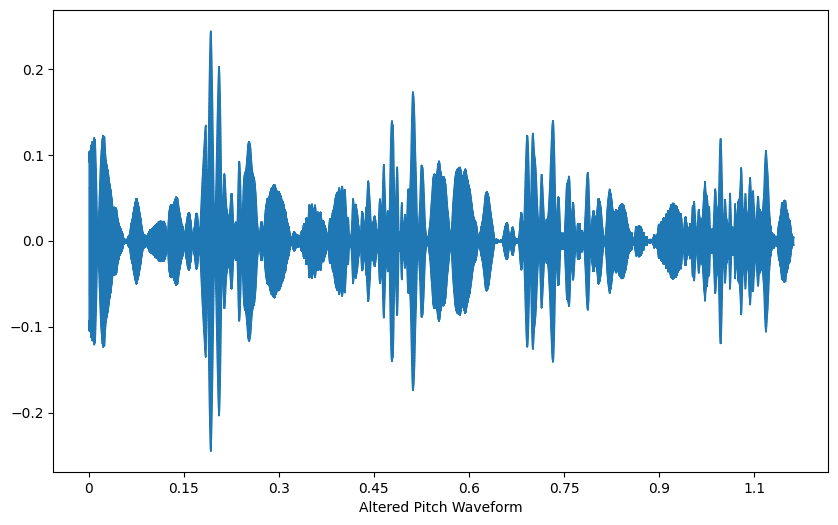

In [29]:
pitch_audio = librosa.effects.pitch_shift(waveform, sr=sr, n_steps=4)

plt.figure(figsize=(10, 6))
librosa.display.waveshow(stretched_waveform, sr=sr)
plt.xlabel("Altered Pitch Waveform")

### Visualize alltogether

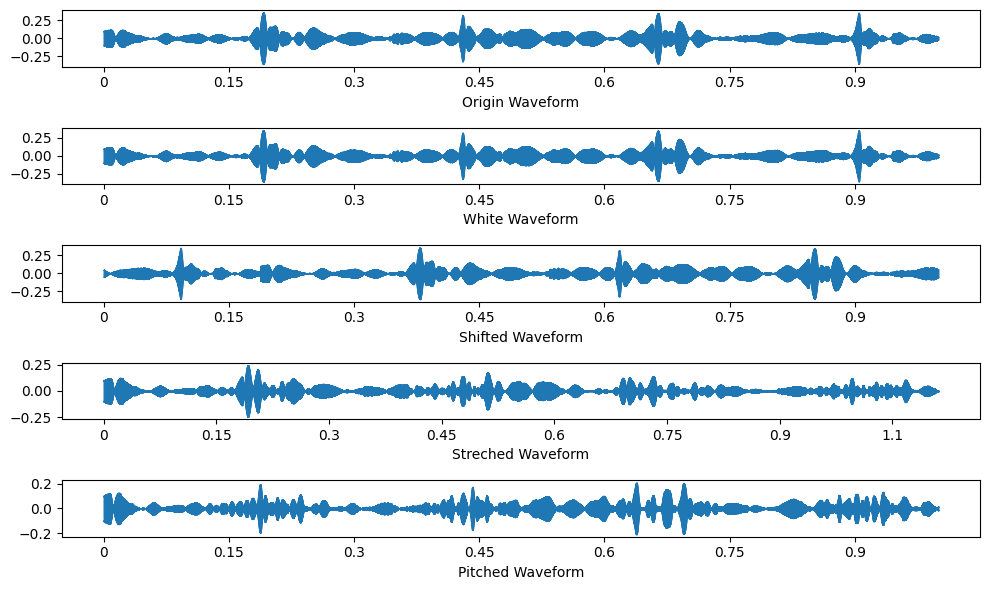

In [ ]:
fig, ax = plt.subplots(5, 1, figsize=(10, 6))

librosa.display.waveshow(waveform, sr=sr, ax=ax[0])
ax[0].set_xlabel("Original Waveform")

librosa.display.waveshow(waveform_white_noise, sr=sr, ax=ax[1])
ax[1].set_xlabel("White Noise Waveform")

librosa.display.waveshow(shifted_waveform, sr=sr, ax=ax[2])
ax[2].set_xlabel("Shifted Waveform")

librosa.display.waveshow(stretched_waveform, sr=sr, ax=ax[3])
ax[3].set_xlabel("Streched Waveform")

librosa.display.waveshow(pitch_audio, sr=sr, ax=ax[4])
ax[4].set_xlabel("Pitched Waveform")

plt.tight_layout()

#### You can listen the difference between each augmented waveform.

Again, for clear visualization we are only using 1 seconds of waveform, to hear it clearly use full length waveform.

In [31]:
from IPython.display import Audio

Audio(waveform, rate=sr)

In [32]:
Audio(waveform_white_noise, rate=sr)

In [33]:
Audio(shifted_waveform, rate=sr)

In [34]:
Audio(stretched_waveform, rate=sr)

In [35]:
Audio(pitch_audio, rate=sr)

#### Have you noiced? All the above audio has same function, but little difference. 